In [39]:
# Math & Data manipulation
import copy
import json
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import sympy as sym
import pooch
import os
from pathlib import Path
import gdown

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#import plotnine

# Single-cell analysis
import scanpy as sc
import anndata as ad

# Machine Learning & Deep Learning
#import scvi
#import sklearn
import torch


import scgpt as scg
from scgpt.tasks import GeneEmbedding
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.model import TransformerModel
from scgpt.preprocess import Preprocessor
from scgpt.utils import set_seed



import scib

In [40]:
"""
Calculate the metrics for integration results
"""
def scib_eval(adata, batch_key, cell_type_key, embed_key):
    results = scib.metrics.metrics(
        adata,
        adata_int=adata,
        batch_key=batch_key,
        label_key=cell_type_key,
        embed=embed_key,
        isolated_labels_asw_=False,
        silhouette_=True,
        hvg_score_=False,
        graph_conn_=True,
        pcr_=True,
        isolated_labels_f1_=False,
        trajectory_=False,
        nmi_=True,  # use the clustering, bias to the best matching
        ari_=True,  # use the clustering, bias to the best matching
        cell_cycle_=False,
        kBET_=False,  # kBET return nan sometimes, need to examine
        ilisi_=False,
        clisi_=False,
    )
    result_dict = results[0].to_dict()
    
    # compute avgBIO metrics
    result_dict["avg_bio"] = np.mean(
        [
            result_dict["NMI_cluster/label"],
            result_dict["ARI_cluster/label"],
            result_dict["ASW_label"],
        ]
    )
    
    # compute avgBATCH metrics
    result_dict["avg_batch"] = np.mean(
        [
            result_dict["graph_conn"],
            result_dict["ASW_label/batch"],
        ]
    )
    
    result_dict = {k: v for k, v in result_dict.items() if not np.isnan(v)}
    
    return result_dict

In [41]:
adata = sc.read_h5ad("data/adata_embedded.h5ad")
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
print(np.isnan(X).sum(), "NaNs across", X.shape)

0 NaNs across (49444, 1916)


In [42]:
# 1. Übersicht - obsm-Einträge werden hier aufgelistet
print(adata)
print('obsm keys:', list(adata.obsm.keys()))



AnnData object with n_obs × n_vars = 49444 × 1916
    obs: 'library_uuid', 'assay_ontology_term_id', 'mapped_reference_annotation', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_state', 'suspension_enriched_cell_types', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'Processing_Cohort', 'ct_cov', 'ind_cov', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', '_scvi_batch', '_scvi_labels'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensembl_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts'

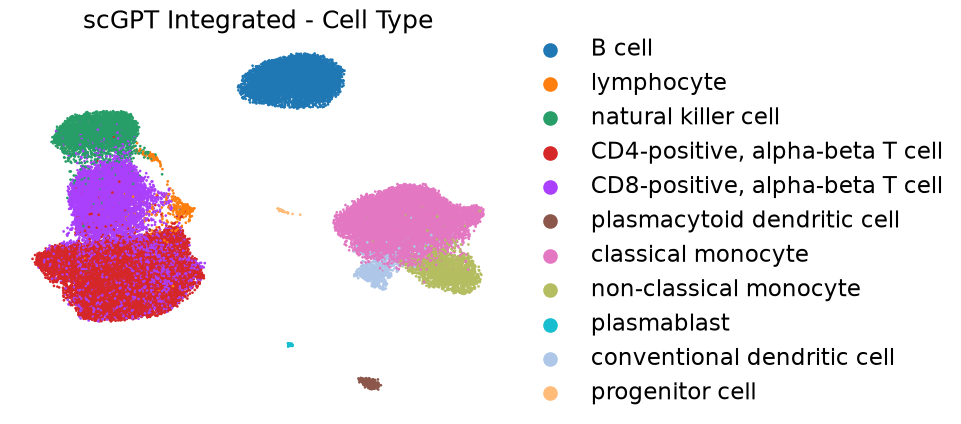

In [43]:
# --- Compute UMAP from scGPT embedding ---
sc.pp.neighbors(adata, use_rep="X_scGPT", key_added="scgpt")
sc.tl.umap(adata, neighbors_key="scgpt")
adata.obsm["X_umap_scgpt"] = adata.obsm.pop("X_umap")  # keep it separate from the other UMAPs

# --- scGPT Integrated ---
sc.pl.embedding(
    adata,
    basis="X_umap_scgpt",
    color=["cell_type"],
    title=["scGPT Integrated - Cell Type"],
    ncols=2,
    size=15,
    frameon=False,
)

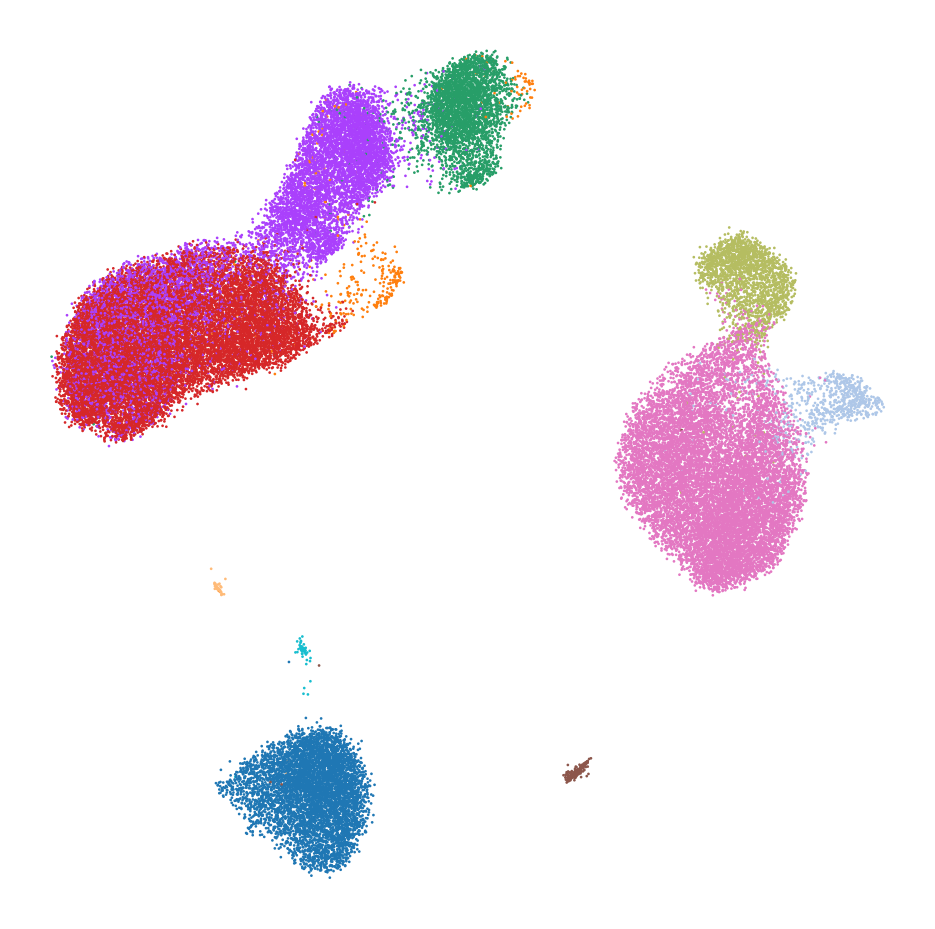

In [44]:
import matplotlib.pyplot as plt
MM = 1 / 25.4

fig, ax = plt.subplots(figsize=(300 * MM, 300 * MM))
sc.pl.embedding(
    adata,
    basis="X_umap_pca",
    color="cell_type",
    title="",
    size=15,
    frameon=False,
    legend_loc=None,
    ax=ax,
    show=False,
)
fig.savefig("scgpt_umap.pdf", dpi=300)   # exactly 70×70 mm
plt.show()

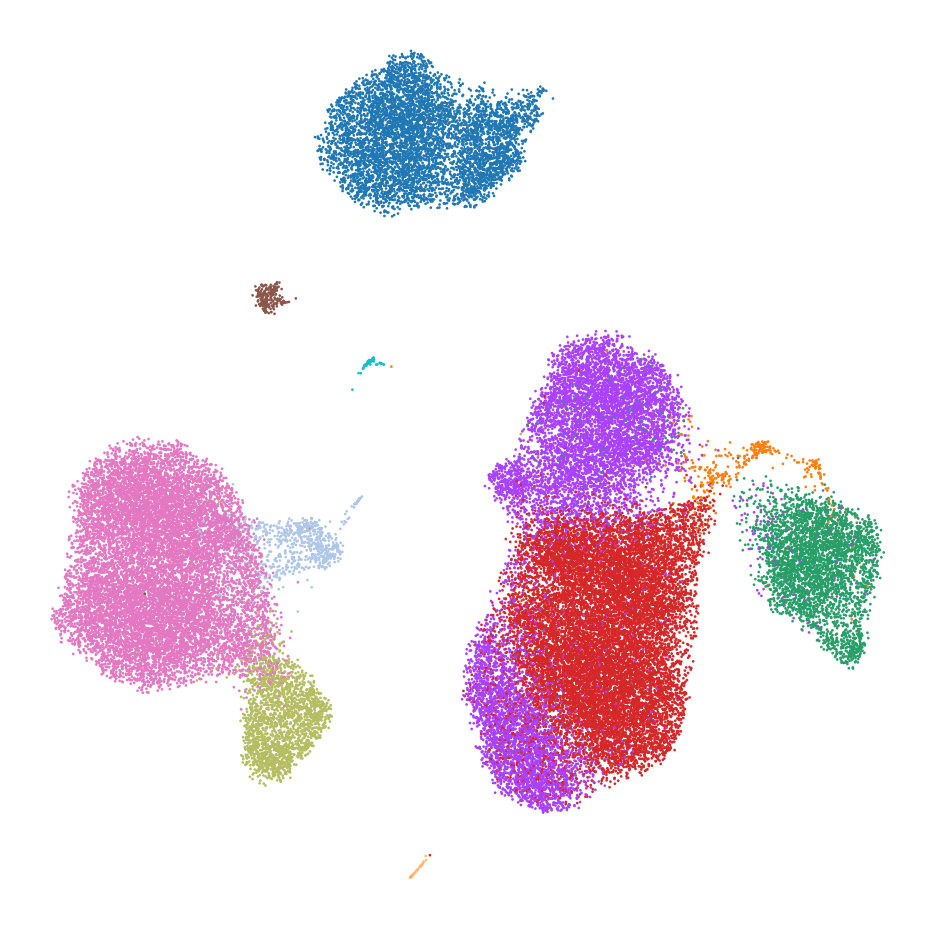

In [45]:
import matplotlib.pyplot as plt
MM = 1 / 25.4

fig, ax = plt.subplots(figsize=(300 * MM, 300 * MM))
sc.pl.embedding(
    adata,
    basis="X_umap_scvi",
    color="cell_type",
    title="",
    size=15,
    frameon=False,
    legend_loc=None,
    ax=ax,
    show=False,
)
fig.savefig("scgpt_umap.pdf", dpi=300)   # exactly 70×70 mm
plt.show()

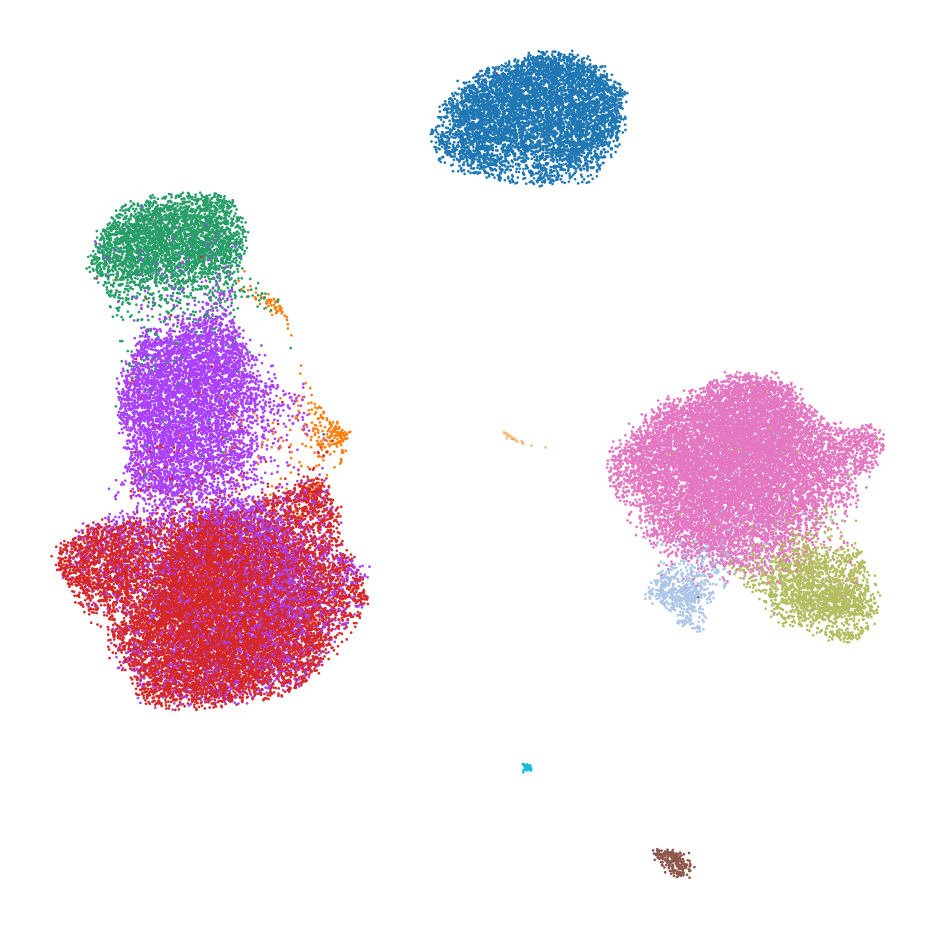

In [46]:
import matplotlib.pyplot as plt
MM = 1 / 25.4

fig, ax = plt.subplots(figsize=(300 * MM, 300 * MM))
sc.pl.embedding(
    adata,
    basis="X_umap_scgpt",
    color="cell_type",
    title="",
    size=15,
    frameon=False,
    legend_loc=None,
    ax=ax,
    show=False,
)
fig.savefig("scgpt_umap.pdf", dpi=300)   # exactly 70×70 mm
plt.show()

In [47]:
adata.uns["pca"].keys()

dict_keys(['connectivities_key', 'distances_key', 'params'])

In [48]:
import numpy as np
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
print(np.isnan(X).sum(), "NaNs across", X.shape)

0 NaNs across (49444, 1916)


In [49]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Representations, per task 3.1:
#   X_pca   -> pre-integration PCA. NOT one of the two graded representations;
#              kept only as an ablation to show integration matters (3.3 material).
#   X_scVI  -> PCA/HVG + scVI batch integration = classical baseline (a)
#   X_scGPT -> zero-shot foundation model embedding = representation (b)
embeddings = ["X_pca", "X_scVI", "X_scGPT"]
OFFICIAL = {"X_scVI": "classical baseline (a)", "X_scGPT": "foundation model (b)"}

labels = adata.obs["cell_type"].values
groups = adata.obs["donor_id"].values

gkf = GroupKFold(n_splits=5)
all_classes = np.unique(labels)  # fixed across folds so macro-F1 is comparable
results = {}

for rep in embeddings:
    X = adata.obsm[rep]
    fold_metrics = []
    for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, labels, groups)):
        # Evaluation A requires disjoint donor sets — verify it, don't just assume it
        assert set(groups[train_idx]).isdisjoint(groups[test_idx]), "donor leaked across split!"

        scaler = StandardScaler().fit(X[train_idx])
        X_train, X_test = scaler.transform(X[train_idx]), scaler.transform(X[test_idx])
        y_train, y_test = labels[train_idx], labels[test_idx]

        missing = set(all_classes) - set(y_test)
        if missing:
            print(f"[{rep} fold {fold_i}] cell types absent from test set: {sorted(missing)}")

        clf = KNeighborsClassifier(n_neighbors=30)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        fold_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "macro_f1": f1_score(y_test, y_pred, average="macro",
                                  labels=all_classes, zero_division=0),
            "report": classification_report(y_test, y_pred, labels=all_classes,
                                             output_dict=True, zero_division=0),
        })
    results[rep] = fold_metrics

In [50]:
for rep in embeddings:
    print(rep, adata.obsm[rep].shape)

X_pca (49444, 50)
X_scVI (49444, 10)
X_scGPT (49444, 512)


In [51]:
import pandas as pd

summary_rows = []
for rep, fold_metrics in results.items():
    accs = [f["accuracy"] for f in fold_metrics]
    f1s = [f["macro_f1"] for f in fold_metrics]
    summary_rows.append({
        "embedding": rep,
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
        "macro_f1_mean": np.mean(f1s),
        "macro_f1_std": np.std(f1s),
    })

summary_df = pd.DataFrame(summary_rows).set_index("embedding")
print(summary_df)

           accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std
embedding                                                          
X_pca           0.873288      0.003136       0.874599      0.008881
X_scVI          0.957850      0.001128       0.941277      0.006353
X_scGPT         0.926357      0.003183       0.922895      0.004332


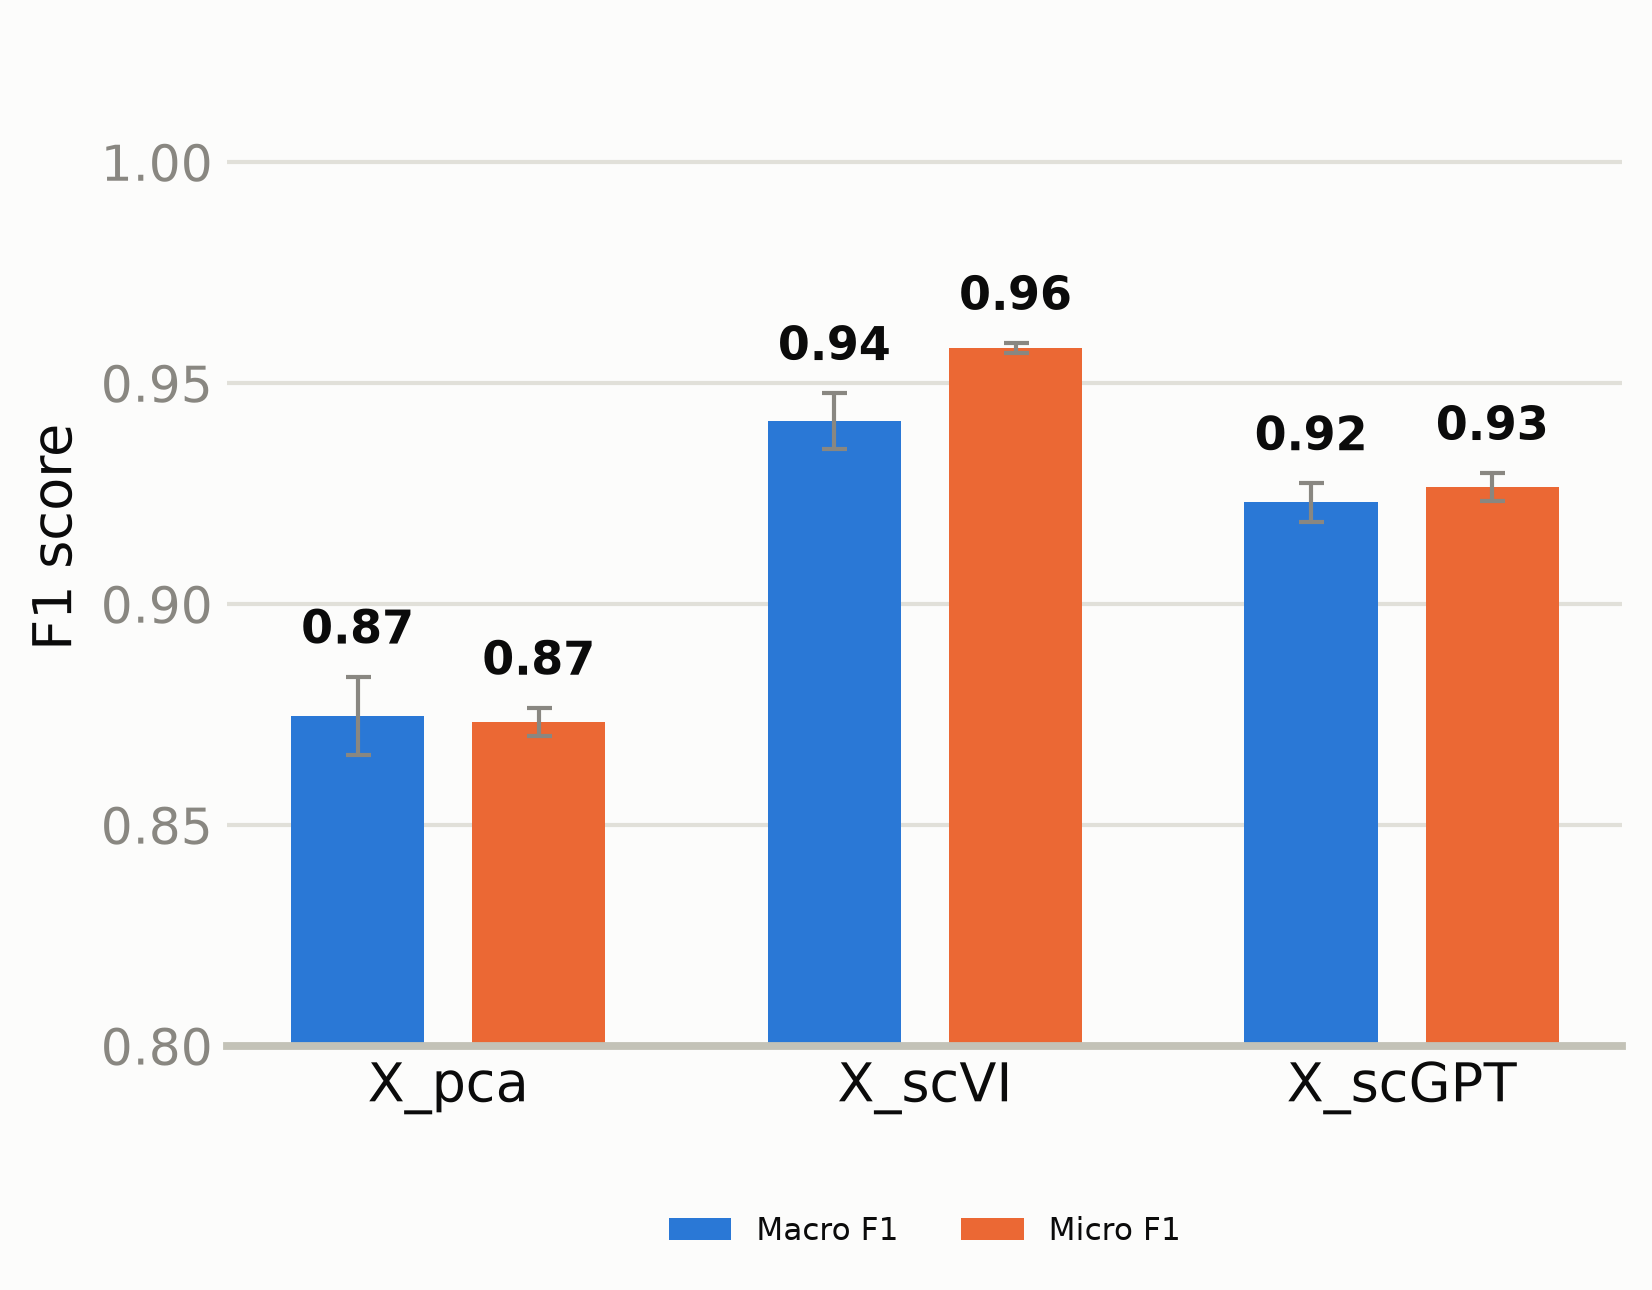

In [61]:
bar_w = 0.28
gap = 0.10

fig, ax = plt.subplots(figsize=(6, 4.4), dpi=300)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

bars_macro = ax.bar(
    x - (bar_w + gap) / 2, summary_df["macro_f1_mean"], width=bar_w,
    yerr=summary_df["macro_f1_std"], capsize=3,
    color=COLOR_MACRO, edgecolor="none",
    error_kw=dict(ecolor=COLOR_TEXT_MUTED, elinewidth=1, capthick=1),
    label="Macro F1",
)
bars_micro = ax.bar(
    x + (bar_w + gap) / 2, summary_df["accuracy_mean"], width=bar_w,
    yerr=summary_df["accuracy_std"], capsize=3,
    color=COLOR_MICRO, edgecolor="none",
    error_kw=dict(ecolor=COLOR_TEXT_MUTED, elinewidth=1, capthick=1),
    label="Micro F1",
)

for bars, errs in (
    (bars_macro, summary_df["macro_f1_std"]),
    (bars_micro, summary_df["accuracy_std"]),
):
    for rect, err in zip(bars, errs):
        h = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2, h + err + 0.005,
            f"{h:.2f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=COLOR_TEXT_PRIMARY,
        )

ax.yaxis.grid(True, color=COLOR_GRID, linewidth=1)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(COLOR_AXIS)

ax.set_xticks(x)
ax.set_xticklabels(embeddings, color=COLOR_TEXT_PRIMARY, fontsize=13)

ax.set_ylim(0.8, 1.03)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.tick_params(axis="y", colors=COLOR_TEXT_MUTED, length=0, labelsize=12)
ax.tick_params(axis="x", length=0)

ax.set_ylabel("F1 score", color=COLOR_TEXT_PRIMARY, fontsize=13)
# no title — figure caption carries that info in the paper

ax.legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14),
    ncol=2, fontsize=7.5, labelcolor=COLOR_TEXT_PRIMARY,
)

fig.savefig(
    "embedding_f1_barplot.png", facecolor=fig.get_facecolor(),
    bbox_inches="tight",
)
plt.show()

In [63]:
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def paired_wilcoxon_report(results, metric="macro_f1"):
    reps = list(results.keys())
    rows = []
    for a, b in combinations(reps, 2):
        scores_a = np.array([f[metric] for f in results[a]])
        scores_b = np.array([f[metric] for f in results[b]])
        diffs = scores_a - scores_b

        n_nonzero = np.count_nonzero(diffs)
        if n_nonzero < 1:
            # every fold tied exactly -> nothing to test
            stat, p = np.nan, 1.0
        else:
            # zero_method="pratt" keeps zero-differences in the ranking
            # instead of dropping them, which matters when n is this small
            stat, p = wilcoxon(scores_a, scores_b, zero_method="pratt")

        rows.append({
            "comparison": f"{a} vs {b}",
            "median_diff": np.median(diffs),
            "n_folds": len(diffs),
            "n_nonzero_diffs": n_nonzero,
            "statistic": stat,
            "p_raw": p,
        })

    report_df = pd.DataFrame(rows)
    reject, p_adj, _, _ = multipletests(report_df["p_raw"], method="holm")
    report_df["p_holm"] = p_adj
    report_df["significant (holm, α=0.05)"] = reject
    return report_df

print("Macro F1")
print(paired_wilcoxon_report(results, metric="macro_f1"))
print()
print("Accuracy (micro F1)")
print(paired_wilcoxon_report(results, metric="accuracy"))

Macro F1
          comparison  median_diff  n_folds  n_nonzero_diffs  statistic  \
0    X_pca vs X_scVI    -0.068291        5                5        0.0   
1   X_pca vs X_scGPT    -0.046447        5                5        0.0   
2  X_scVI vs X_scGPT     0.017976        5                5        0.0   

    p_raw  p_holm  significant (holm, α=0.05)  
0  0.0625  0.1875                       False  
1  0.0625  0.1875                       False  
2  0.0625  0.1875                       False  

Accuracy (micro F1)
          comparison  median_diff  n_folds  n_nonzero_diffs  statistic  \
0    X_pca vs X_scVI    -0.085865        5                5        0.0   
1   X_pca vs X_scGPT    -0.053202        5                5        0.0   
2  X_scVI vs X_scGPT     0.030064        5                5        0.0   

    p_raw  p_holm  significant (holm, α=0.05)  
0  0.0625  0.1875                       False  
1  0.0625  0.1875                       False  
2  0.0625  0.1875                       

In [53]:
per_class_rows = []
for rep, fold_metrics in results.items():
    for fold_i, f in enumerate(fold_metrics):
        report = f["report"]
        for class_name, metrics in report.items():
            if class_name in ("accuracy", "macro avg", "weighted avg"):
                continue
            per_class_rows.append({
                "embedding": rep,
                "fold": fold_i,
                "cell_type": class_name,
                "f1": metrics["f1-score"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "support": metrics["support"],
            })

per_class_df = pd.DataFrame(per_class_rows)

# average F1 per embedding x cell type across folds
per_class_pivot = (
    per_class_df.groupby(["cell_type", "embedding"])["f1"]
    .mean()
    .unstack("embedding")
    .sort_values(by=per_class_df["embedding"].unique()[0], ascending=False)
)
print(per_class_pivot)

embedding                           X_pca   X_scGPT    X_scVI
cell_type                                                    
plasmacytoid dendritic cell      0.992736  0.992184  0.990795
B cell                           0.992356  0.998896  0.999268
classical monocyte               0.978215  0.981999  0.987049
plasmablast                      0.977778  0.986667  0.964385
non-classical monocyte           0.957509  0.931085  0.953039
conventional dendritic cell      0.905937  0.865355  0.893583
natural killer cell              0.849687  0.955708  0.969864
CD4-positive, alpha-beta T cell  0.830836  0.908305  0.948134
lymphocyte                       0.758211  0.769475  0.813783
CD8-positive, alpha-beta T cell  0.703904  0.826405  0.914625
progenitor cell                  0.673424  0.935766  0.919527


embedding                           X_pca   X_scGPT    X_scVI
cell_type                                                    
B cell                           0.992356  0.998896  0.999268
plasmacytoid dendritic cell      0.992736  0.992184  0.990795
classical monocyte               0.978215  0.981999  0.987049
plasmablast                      0.977778  0.986667  0.964385
non-classical monocyte           0.957509  0.931085  0.953039
natural killer cell              0.849687  0.955708  0.969864
CD4-positive, alpha-beta T cell  0.830836  0.908305  0.948134
conventional dendritic cell      0.905937  0.865355  0.893583
progenitor cell                  0.673424  0.935766  0.919527
CD8-positive, alpha-beta T cell  0.703904  0.826405  0.914625
lymphocyte                       0.758211  0.769475  0.813783


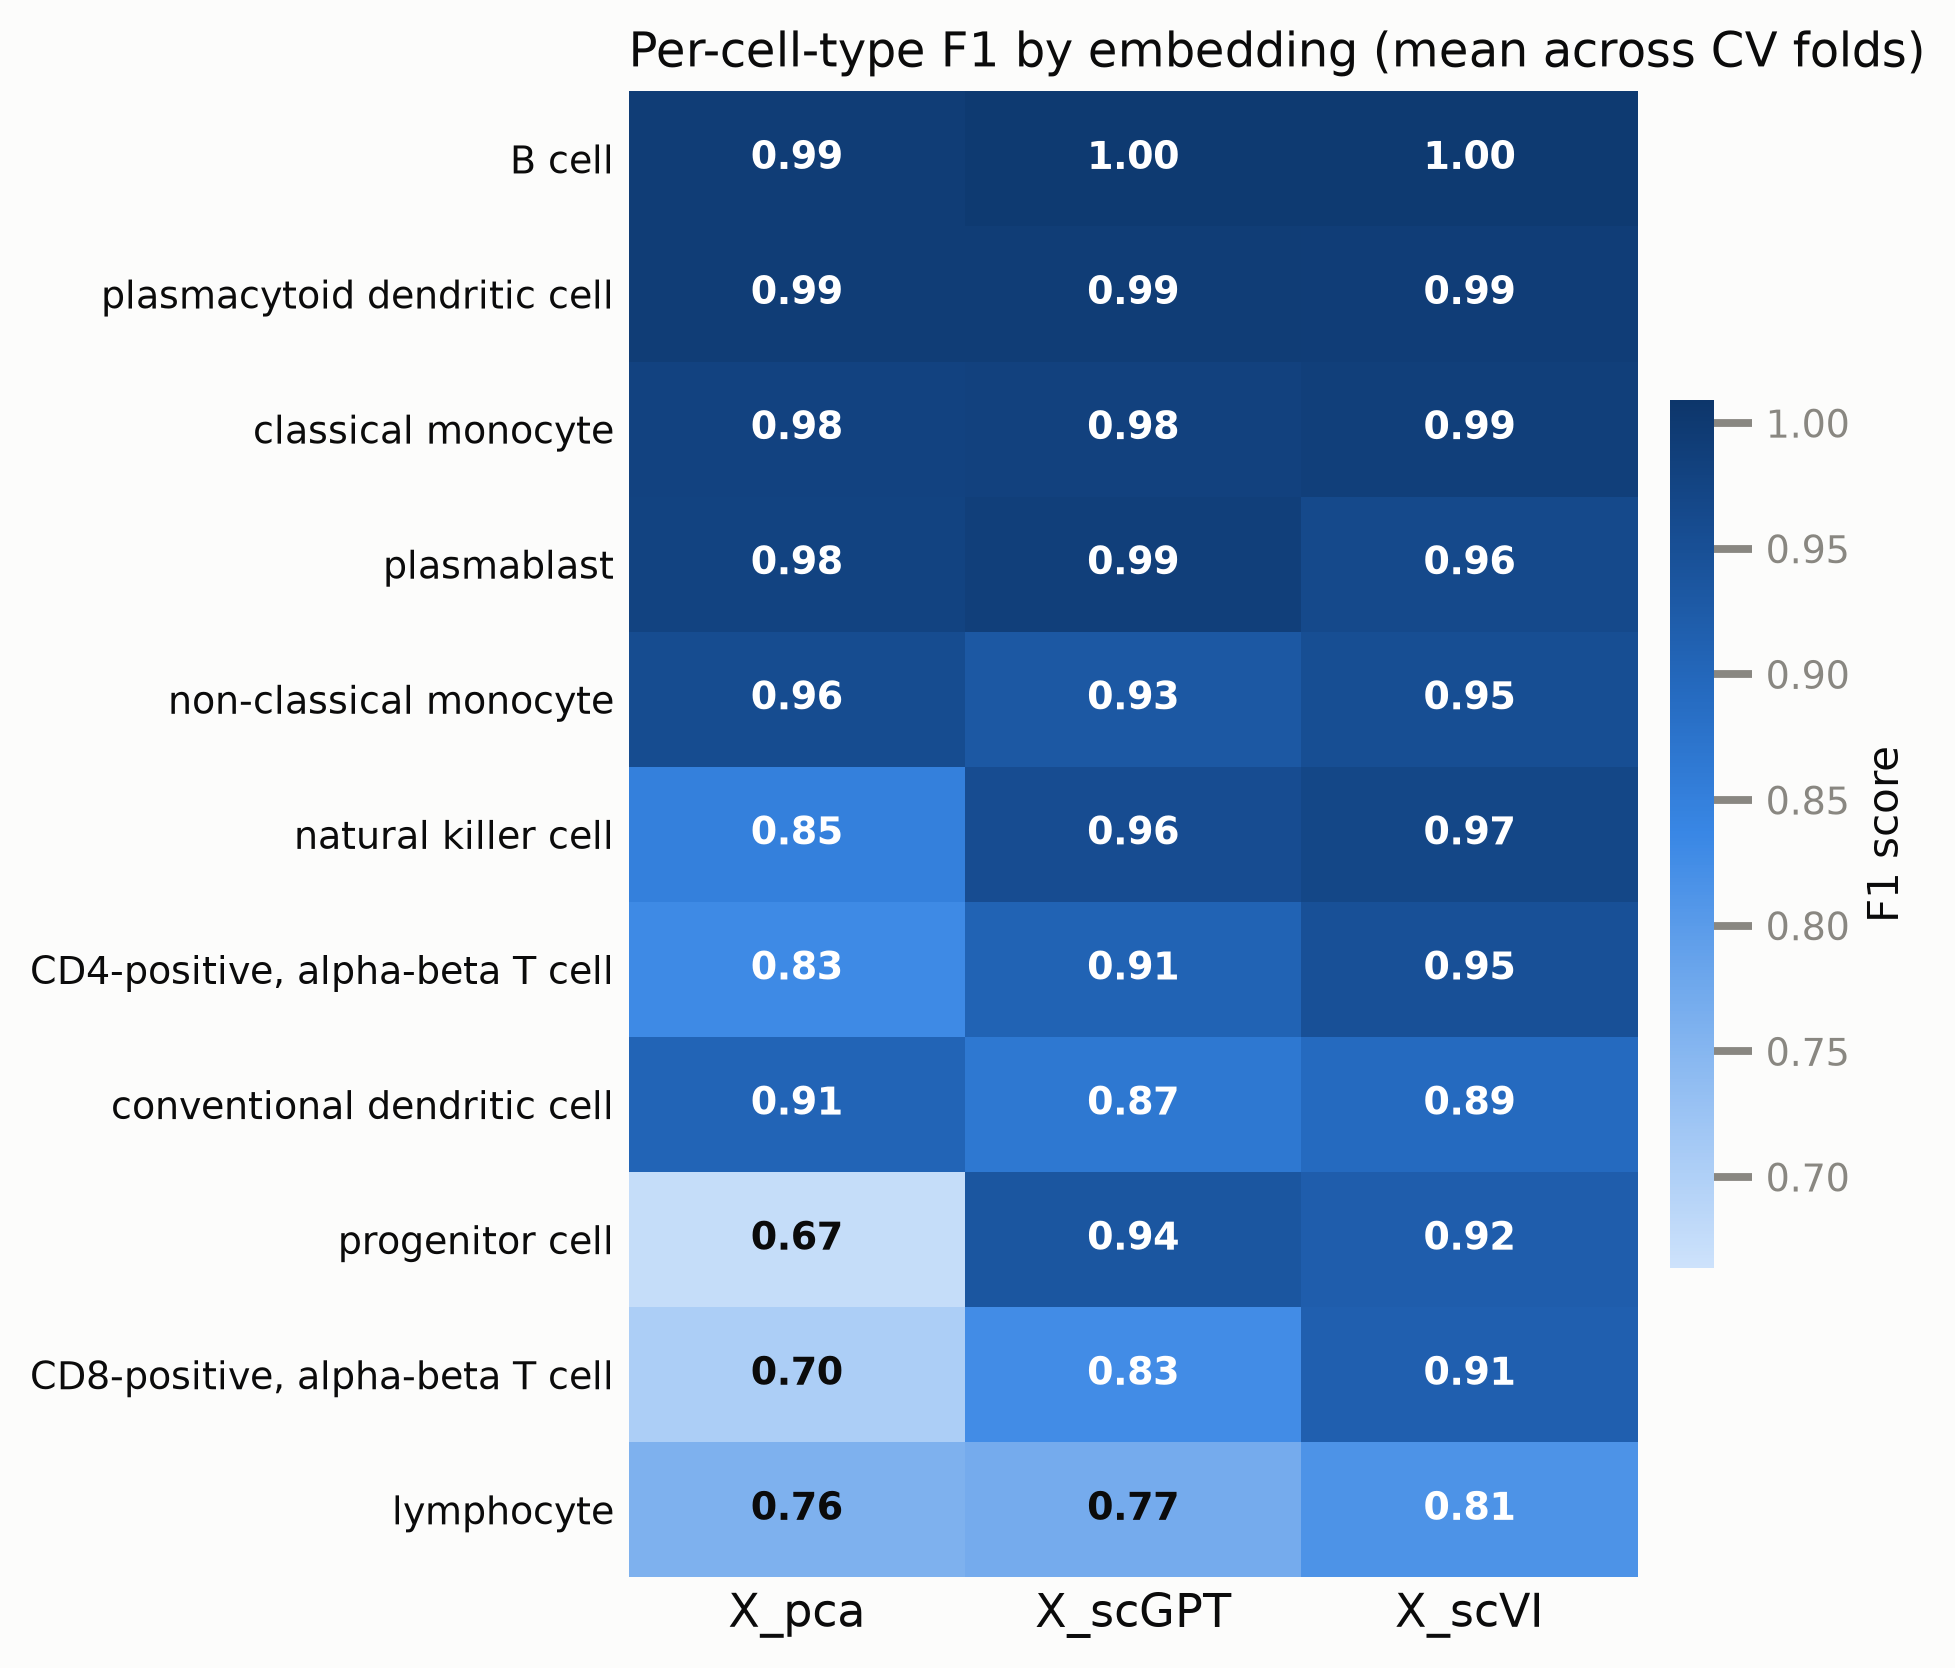

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# --- your existing per-class aggregation ---
per_class_rows = []
for rep, fold_metrics in results.items():
    for fold_i, f in enumerate(fold_metrics):
        report = f["report"]
        for class_name, metrics in report.items():
            if class_name in ("accuracy", "macro avg", "weighted avg"):
                continue
            per_class_rows.append({
                "embedding": rep,
                "fold": fold_i,
                "cell_type": class_name,
                "f1": metrics["f1-score"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "support": metrics["support"],
            })

per_class_df = pd.DataFrame(per_class_rows)

per_class_pivot = (
    per_class_df.groupby(["cell_type", "embedding"])["f1"]
    .mean()
    .unstack("embedding")
)
per_class_pivot = per_class_pivot.loc[
    per_class_pivot.mean(axis=1).sort_values(ascending=False).index
]
print(per_class_pivot)

# --- heatmap ---
COLOR_TEXT_PRIMARY = "#0b0b0b"
COLOR_TEXT_MUTED = "#898781"
SURFACE = "#fcfcfb"

blue_ramp = [
    "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
    "#256abf", "#184f95", "#0d366b",
]
cmap = LinearSegmentedColormap.from_list("f1_blue", blue_ramp)

data = per_class_pivot.values
n_rows, n_cols = data.shape

# scale the colormap to the actual data range instead of the full 0-1 scale
vmin = np.nanmin(data)
vmax = np.nanmax(data)
# small padding so the extreme cells aren't pinned to the ramp's very ends
pad = 0.03 * (vmax - vmin) if vmax > vmin else 0.01
vmin, vmax = vmin - pad, vmax + pad
norm = Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(1.6 * n_cols + 2, 0.4 * n_rows + 1.5), dpi=300)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

im = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(n_cols))
ax.set_xticklabels(per_class_pivot.columns, color=COLOR_TEXT_PRIMARY, fontsize=11)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(per_class_pivot.index, color=COLOR_TEXT_PRIMARY, fontsize=9)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

def _text_color(val):
    # perceptual luminance of the cell's actual mapped color, not a fixed
    # 0-1 threshold — stays correct regardless of vmin/vmax scaling
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "#ffffff" if luminance < 0.6 else COLOR_TEXT_PRIMARY

for i in range(n_rows):
    for j in range(n_cols):
        val = data[i, j]
        if np.isnan(val):
            continue
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=9, fontweight="bold", color=_text_color(val))

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label("F1 score", color=COLOR_TEXT_PRIMARY, fontsize=10)
cbar.ax.yaxis.set_tick_params(color=COLOR_TEXT_MUTED, labelcolor=COLOR_TEXT_MUTED, labelsize=9)
cbar.outline.set_visible(False)

ax.set_title(
    "Per-cell-type F1 by embedding (mean across CV folds)",
    color=COLOR_TEXT_PRIMARY, loc="left", fontsize=11.5,
)

fig.tight_layout()
fig.savefig(
    "per_celltype_f1_heatmap.png", facecolor=fig.get_facecolor(),
    bbox_inches="tight",
)
plt.show()

In [55]:
low_support = per_class_df[per_class_df["support"] < 10]
print(low_support[["embedding", "fold", "cell_type", "support"]].sort_values("support"))

# classes that don't appear in every fold for every embedding
n_folds = per_class_df["fold"].nunique()
counts = per_class_df.groupby(["embedding", "cell_type"])["fold"].nunique()
missing = counts[counts < n_folds]
print(missing)

    embedding  fold        cell_type  support
8       X_pca     0      plasmablast      6.0
120   X_scGPT     0  progenitor cell      6.0
118   X_scGPT     0      plasmablast      6.0
98     X_scVI     3  progenitor cell      6.0
65     X_scVI     0  progenitor cell      6.0
63     X_scVI     0      plasmablast      6.0
153   X_scGPT     3  progenitor cell      6.0
10      X_pca     0  progenitor cell      6.0
43      X_pca     3  progenitor cell      6.0
19      X_pca     1      plasmablast      7.0
129   X_scGPT     1      plasmablast      7.0
74     X_scVI     1      plasmablast      7.0
32      X_pca     2  progenitor cell      8.0
142   X_scGPT     2  progenitor cell      8.0
85     X_scVI     2      plasmablast      8.0
87     X_scVI     2  progenitor cell      8.0
30      X_pca     2      plasmablast      8.0
140   X_scGPT     2      plasmablast      8.0
Series([], Name: fold, dtype: int64)


In [64]:
per_class_full = (
    per_class_df.groupby(["cell_type", "embedding"])[["precision", "recall", "f1", "support"]]
    .mean()
    .round(3)
)
per_class_full = per_class_full.reindex(per_class_pivot.index, level="cell_type")
print(per_class_full)

                                           precision  recall     f1  support
cell_type                       embedding                                   
B cell                          X_pca          0.999   0.985  0.992   1173.6
                                X_scGPT        0.998   0.999  0.999   1173.6
                                X_scVI         0.999   0.999  0.999   1173.6
plasmacytoid dendritic cell     X_pca          1.000   0.986  0.993     40.4
                                X_scGPT        1.000   0.985  0.992     40.4
                                X_scVI         0.996   0.986  0.991     40.4
classical monocyte              X_pca          0.982   0.975  0.978   2470.8
                                X_scGPT        0.973   0.992  0.982   2470.8
                                X_scVI         0.980   0.994  0.987   2470.8
plasmablast                     X_pca          1.000   0.960  0.978     10.2
                                X_scGPT        1.000   0.975  0.987     10.2

In [67]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

embeddings = ["X_pca", "X_scVI", "X_scGPT"]
OFFICIAL = {"X_scVI": "classical baseline (a)", "X_scGPT": "foundation model (b)"}

labels = adata.obs["cell_type"].values
groups = adata.obs["donor_id"].values

gkf = GroupKFold(n_splits=5)
all_classes = np.unique(labels)
results = {}

for rep in embeddings:
    X = adata.obsm[rep]
    fold_metrics = []
    for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, labels, groups)):
        assert set(groups[train_idx]).isdisjoint(groups[test_idx]), "donor leaked across split!"

        scaler = StandardScaler().fit(X[train_idx])
        X_train, X_test = scaler.transform(X[train_idx]), scaler.transform(X[test_idx])
        y_train, y_test = labels[train_idx], labels[test_idx]

        missing = set(all_classes) - set(y_test)
        if missing:
            print(f"[{rep} fold {fold_i}] cell types absent from test set: {sorted(missing)}")

        clf = KNeighborsClassifier(n_neighbors=30)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        fold_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "macro_f1": f1_score(y_test, y_pred, average="macro",
                                  labels=all_classes, zero_division=0),
            "report": classification_report(y_test, y_pred, labels=all_classes,
                                             output_dict=True, zero_division=0),
            "confusion_matrix": confusion_matrix(y_test, y_pred, labels=all_classes,
                                                  normalize="true"),
        })
    results[rep] = fold_metrics

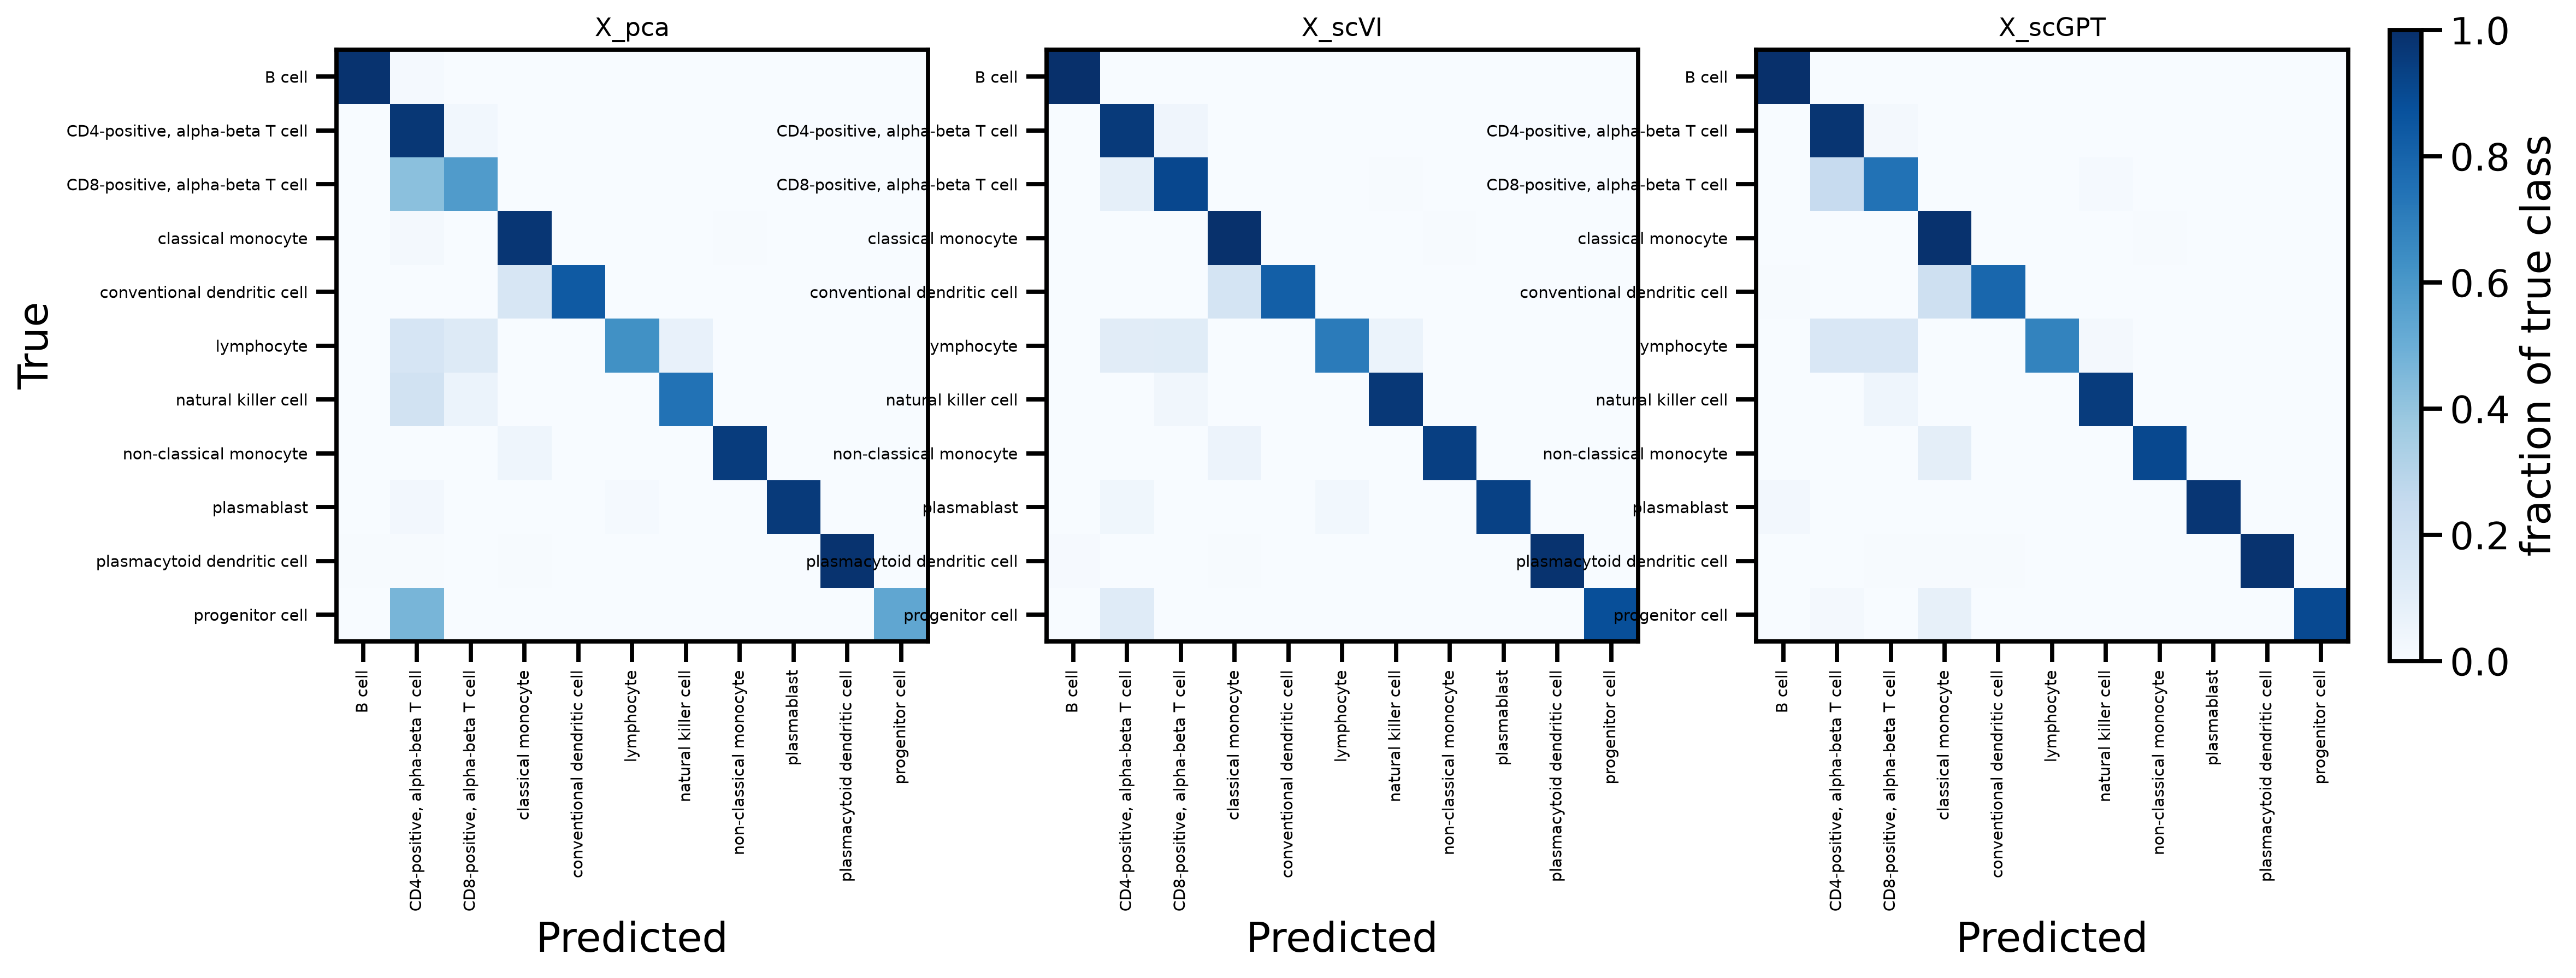

In [75]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(embeddings), figsize=(5.5 * len(embeddings), 5), dpi=300)
if len(embeddings) == 1:
    axes = [axes]

for ax, rep in zip(axes, embeddings):
    cms = np.stack([f["confusion_matrix"] for f in results[rep]])
    mean_cm = cms.mean(axis=0)

    im = ax.imshow(mean_cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(all_classes)))
    ax.set_xticklabels(all_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(len(all_classes)))
    ax.set_yticklabels(all_classes, fontsize=7)
    ax.set_title(rep, fontsize=11)
    ax.set_xlabel("Predicted")
    if ax is axes[0]:
        ax.set_ylabel("True")

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="fraction of true class")
fig.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

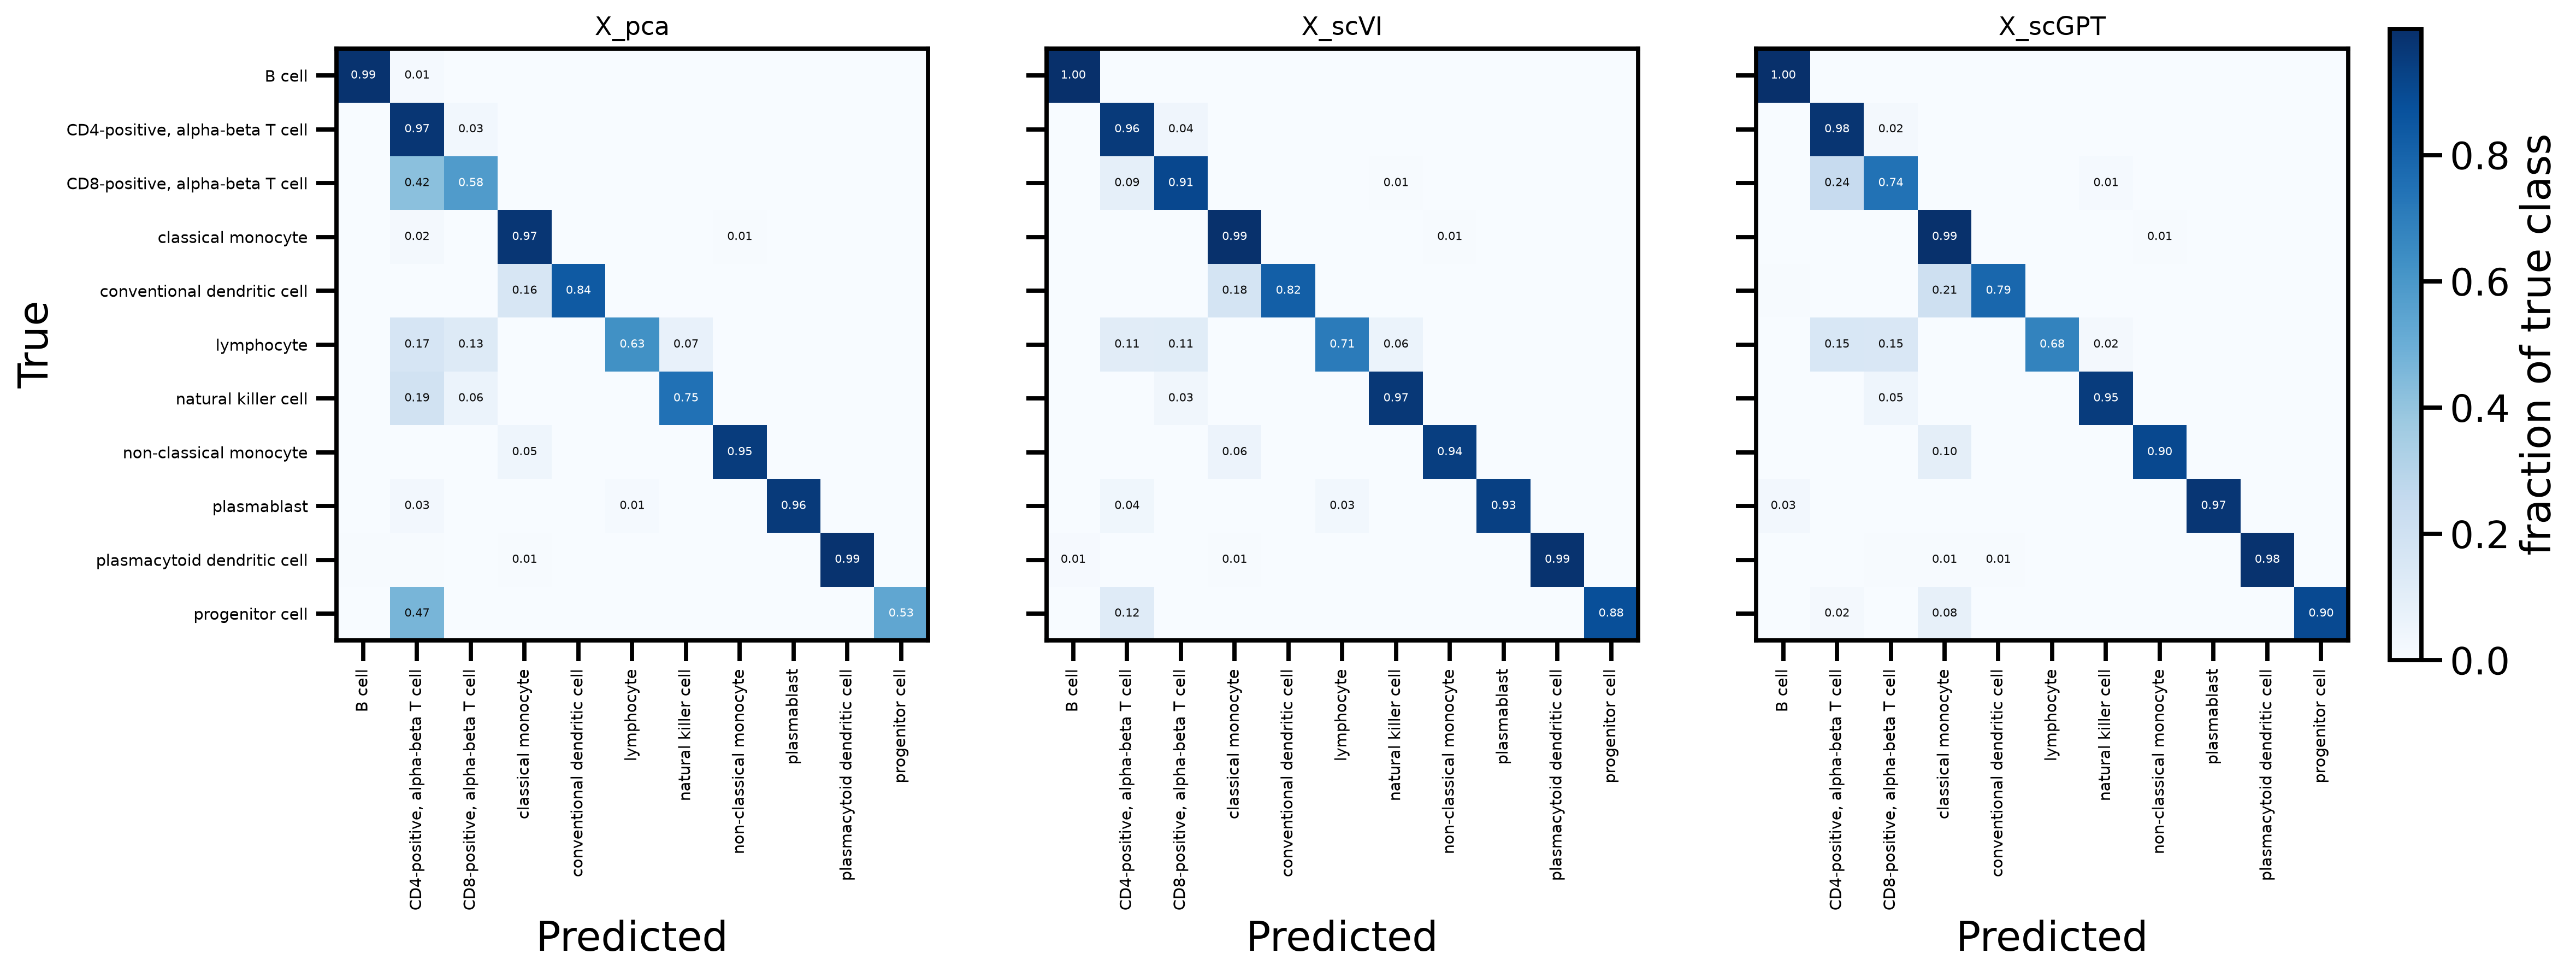

In [79]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import Normalize

mean_cms = {}
for rep in embeddings:
    cms = np.stack([f["confusion_matrix"] for f in results[rep]])
    mean_cms[rep] = cms.mean(axis=0)

all_vals = np.concatenate([m.ravel() for m in mean_cms.values()])
norm = Normalize(vmin=all_vals.min(), vmax=all_vals.max())
cmap = mpl.colormaps["Blues"]

def _text_color(val):
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "#ffffff" if luminance < 0.6 else "#0b0b0b"

fig, axes = plt.subplots(1, len(embeddings), figsize=(5.5 * len(embeddings), 5), dpi=300)
if len(embeddings) == 1:
    axes = [axes]

for ax, rep in zip(axes, embeddings):
    mat = mean_cms[rep]
    im = ax.imshow(mat, cmap=cmap, norm=norm)

    n_rows, n_cols = mat.shape
    for i in range(n_rows):
        for j in range(n_cols):
            val = mat[i, j]
            label = f"{val:.2f}"
            if label != "0.00":
                ax.text(j, i, label, ha="center", va="center",
                         fontsize=5, color=_text_color(val))

    ax.set_xticks(range(len(all_classes)))
    ax.set_xticklabels(all_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(len(all_classes)))

    if ax is axes[0]:
        ax.set_yticklabels(all_classes, fontsize=7)
        ax.set_ylabel("True")
    else:
        ax.set_yticklabels([])  # keep tick marks, drop the text labels

    ax.set_title(rep, fontsize=11)
    ax.set_xlabel("Predicted")

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="fraction of true class")
fig.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()